# SVM multiclase en Digits

Este notebook compara el coste y la precisión de una aproximación OvR lineal frente a dos variantes OvO (lineal y RBF) y Crammer-Singer sobre las características originales del dataset.
El análisis de reducción de dimensionalidad con PCA se deja en el apéndice al final.

In [6]:
import time

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, LinearSVC

## 1. Configuración del experimento

El conjunto Digits contiene 1797 imágenes de dígitos escritos a mano de tamaño 8×8, lo que resulta en vectores de 64 características por muestra.
El 75 % de los datos se destina a entrenamiento (1347 muestras) y el 25 % restante a test (450 muestras), estratificando por clase para preservar la distribución.

Antes de entrenar los modelos, mostramos 16 ejemplos aleatorios de Digits para visualizar el tipo de imágenes y sus etiquetas.

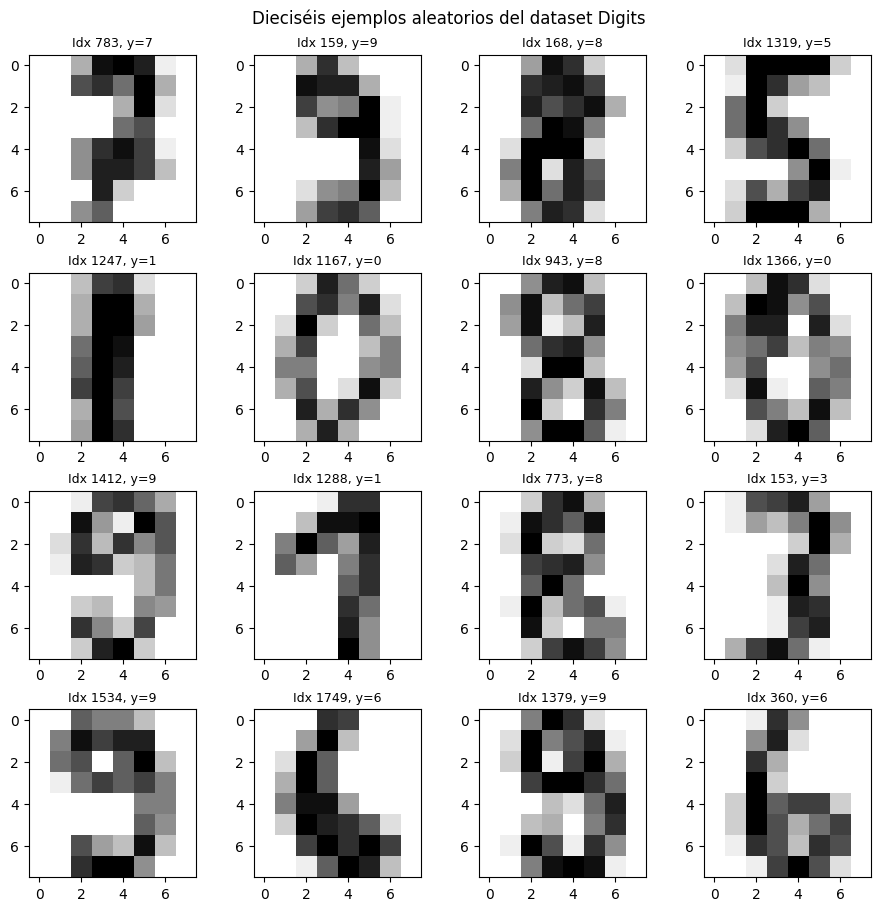

In [7]:
import numpy as np

# Cargar la base de datos
digits = load_digits()

# Visualizar 16 ejemplos aleatorios
rng = np.random.default_rng(42) # Semilla fija para reproducibilidad
indices = rng.choice(len(digits.images), size=16, replace=False) # Selección aleatoria de índices para mostrar

fig, axes = plt.subplots(4, 4, figsize=(9, 9), constrained_layout=True)

for ax, idx in zip(axes.flat, indices):
    ax.imshow(digits.images[idx], cmap='gray_r')
    ax.set_title(f'Idx {idx}, y={digits.target[idx]}', fontsize=9)
    ax.axis('on')

fig.suptitle('Dieciséis ejemplos aleatorios del dataset Digits', fontsize=12)
plt.show()

## 1.1 Modelos evaluados

Comparamos cuatro estrategias de clasificación multiclase que difieren en el esquema de descomposición y en el kernel empleado:

- **OvR lineal (LinearSVC)**: un clasificador binario lineal por clase (10 en total).
- **OvO lineal (SVC)**: un clasificador binario lineal por par de clases ($\binom{10}{2} = 45$ en total).
- **Crammer-Singer (LinearSVC)**: solución directa multiclase que optimiza una única matriz de decisión de tamaño $k \times d$, donde $k$ es el número de clases y $d$ el número de características. En este caso, $k=10$ y $d=64$.
- **OvO RBF (SVC)**: un clasificador binario con kernel RBF por par de clases (45 en total), que introduce no linealidad.

In [8]:
# Usar el dataset ya cargado en la celda anterior
X_digits, y_digits = digits.data, digits.target

# División estratificada con 75% entrenamiento, 25% test
X_tr, X_te, y_tr, y_te = train_test_split(
    X_digits, y_digits, test_size=0.25, random_state=30, stratify=y_digits
)

## 1.2 Definición de Modelos

Definimos una función para instanciar los modelos de forma que podamos reutilizarlos fácilmente a lo largo del notebook con distintos hiperparámetros de regularización ($C$).
Es importante destacar que incluimos el preprocesamiento `StandardScaler` en cada pipeline, dado que los algoritmos SVM (basados en maximizar márgenes matemáticos basados en distancia) son muy sensibles a la escala de las distintas características.

In [9]:
def obtener_modelos(c_ovr=1.0, c_ovo_lin=1.0, c_cs=1.0, c_ovo_rbf=1.0):
    """Devuelve un diccionario con las cuatro configuraciones de modelos.
    Permite especificar el parámetro de regularización C para cada uno de forma individual."""
    return {
        'OvR lineal (LinearSVC)': make_pipeline(
            StandardScaler(),
            LinearSVC(C=c_ovr, multi_class='ovr', max_iter=1000000000, random_state=32)
        ),
        'OvO lineal (SVC)': make_pipeline(
            StandardScaler(),
            SVC(C=c_ovo_lin, kernel='linear', decision_function_shape='ovo')
        ),
        'Crammer-Singer (LinearSVC)': make_pipeline(
            StandardScaler(),
            LinearSVC(C=c_cs, multi_class='crammer_singer', max_iter=1000000000, random_state=32)
        ),
        'OvO RBF (SVC)': make_pipeline(
            StandardScaler(),
            SVC(C=c_ovo_rbf, kernel='rbf', gamma='scale', decision_function_shape='ovo')
        )
    }

## 2. Curvas de aprendizaje
Las curvas de aprendizaje permiten visualizar cómo evoluciona la exactitud en entrenamiento y test al variar el tamaño del conjunto de entrenamiento. Esto ayuda a identificar posibles problemas de overfitting o underfitting en los modelos.

In [10]:
def mostrar_curva_aprendizaje_ax(ax, modelo_nombre, clf, max_prop=0.8, n_puntos=8):
    """Dibuja la curva de aprendizaje para un modelo dado en un eje (Axes) específico."""
    from sklearn.model_selection import learning_curve
    import numpy as np

    train_sizes = np.linspace(0.05, max_prop, n_puntos)
    n_total = X_digits.shape[0]

    train_sizes_abs, train_scores, test_scores = learning_curve(
        clf, X_digits, y_digits, train_sizes=train_sizes, cv=4, scoring='accuracy', n_jobs=-1, random_state=30
    )
    train_sizes_prop = train_sizes_abs / n_total
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    ax.plot(train_sizes_prop, train_mean, 'o-', color='blue', label='Entrenamiento')
    ax.fill_between(train_sizes_prop, train_mean - train_std, train_mean + train_std, color='blue', alpha=0.2)
    ax.plot(train_sizes_prop, test_mean, 'o-', color='orange', label='Test')
    ax.fill_between(train_sizes_prop, test_mean - test_std, test_mean + test_std, color='orange', alpha=0.2)

    c_val = getattr(clf[-1], "C", "-") if hasattr(clf, "steps") else "-"
    ax.set_title(f'{modelo_nombre}\nC = {c_val}')
    ax.set_xlabel('Proporción del conjunto de entrenamiento')
    ax.set_ylabel('Exactitud')
    x_max = min(1.0, train_sizes_prop[-1] + 0.03)
    ax.set_xlim(0, x_max)
    ax.grid(alpha=0.3)
    ax.legend()

/home/hugo/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hugo/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hugo/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hugo/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hugo/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


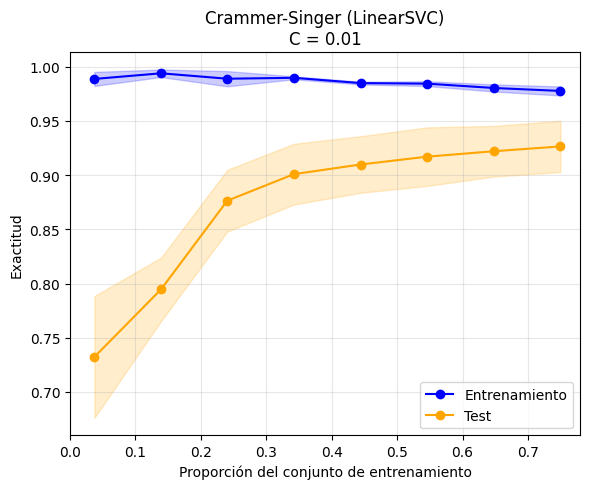

In [11]:
# Usamos la definición base de hiperparámetros C para la curva de aprendizaje (un poco subidos como ejemplo)
configuraciones = obtener_modelos(
    c_ovr=1.0,
    c_ovo_lin=1.0,
    c_cs=0.01,
    c_ovo_rbf=2.5
)

import matplotlib.pyplot as plt

# Seleccionamos un modelo específico para mostrar su curva individualmente
nombre_modelo = 'Crammer-Singer (LinearSVC)'
#'OvO lineal (SVC)'
#'OvR lineal (LinearSVC)'
#'Crammer-Singer (LinearSVC)'
#'OvO RBF (SVC)' 
clf_individual = configuraciones[nombre_modelo]

fig, ax = plt.subplots(figsize=(6, 5))
mostrar_curva_aprendizaje_ax(ax, nombre_modelo, clf_individual, max_prop=1., n_puntos=8)
plt.tight_layout()
plt.show()

## 3. Fijación de hiperparámetros y evaluación

A la vista de las curvas y realizando pruebas adicionales (no mostradas para mantener la brevedad), fijamos una combinación de hiperparámetros y construimos la tabla de resultados finales para observar la exactitud y los tiempos de entrenamiento y predicción.

In [12]:
configuraciones = obtener_modelos(
    c_ovr=0.1,
    c_ovo_lin=0.01,
    c_cs=0.01,
    c_ovo_rbf=0.35
)

/home/hugo/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/home/hugo/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


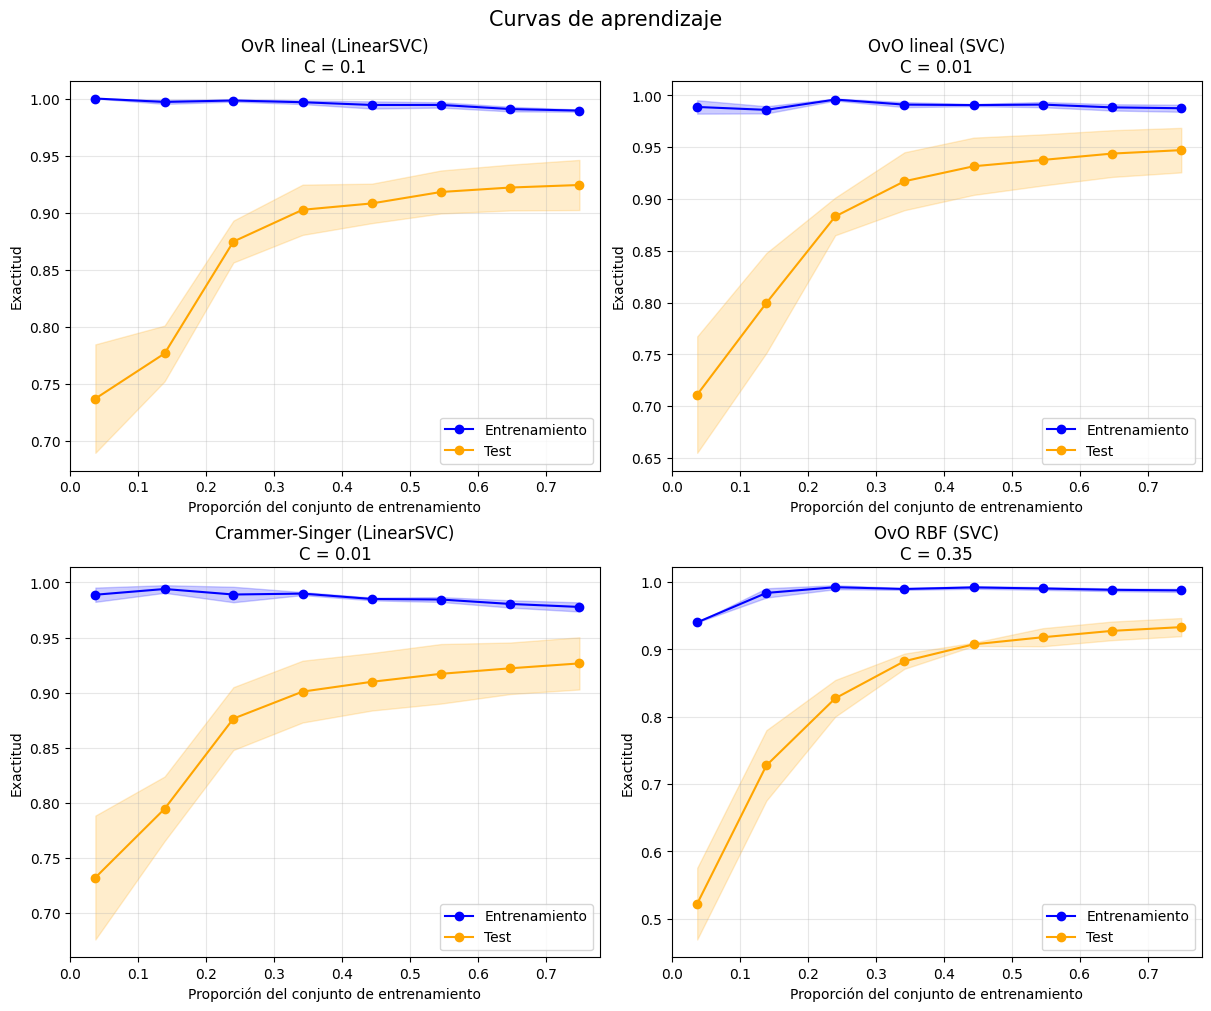

In [13]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
axes = axes.flatten()

for ax, (nombre, clf) in zip(axes, configuraciones.items()):
    mostrar_curva_aprendizaje_ax(ax, nombre, clf, max_prop=1., n_puntos=8)

fig.suptitle(f'Curvas de aprendizaje', fontsize=15)
plt.show()

In [14]:
# Entrenamiento y evaluación: se mide por separado el tiempo de ajuste y el de predicción
resultados = {} # Diccionario para almacenar los resultados de cada configuración
registros = [] # Lista para almacenar los registros que se convertirán en un DataFrame para la tabla de resultados

for nombre, clf in configuraciones.items():
    t0 = time.perf_counter() # Iniciar el cronómetro para medir el tiempo de ajuste
    clf.fit(X_tr, y_tr) # Ajustar el modelo con los datos de entrenamiento
    t_fit = time.perf_counter() - t0 # Calcular el tiempo de ajuste

    t0 = time.perf_counter() # Iniciar el cronómetro para medir el tiempo de predicción
    y_pred = clf.predict(X_te) # Predecir las etiquetas de los datos de test
    t_pred = time.perf_counter() - t0 # Calcular el tiempo de predicción

    acc_test = accuracy_score(y_te, y_pred)   # Exactitud en test
    y_pred_train = clf.predict(X_tr)          # Predicciones en entrenamiento
    acc_train = accuracy_score(y_tr, y_pred_train) # Exactitud en entrenamiento

    resultados[nombre] = {               # Almacenar los resultados en el diccionario
        'clf': clf,                      # El clasificador entrenado
        'y_pred': y_pred,                # Las etiquetas predichas para el conjunto de test
        'acc_test': acc_test,            # La exactitud en test
        'acc_train': acc_train,          # La exactitud en entrenamiento
        't_fit': t_fit,                  # El tiempo de ajuste (en segundos)
        't_pred': t_pred,                # El tiempo de predicción (en segundos)
    }
    registros.append({                   # Agregar un registro a la lista de registros para la tabla de resultados
        'Configuración': nombre,         # El nombre de la configuración (e.g., 'OvR lineal (LinearSVC)')
        'Exactitud test': acc_test,      # La exactitud calculada en test
        'Exactitud train': acc_train,    # La exactitud calculada en entrenamiento
        'Tiempo ajuste (s)': t_fit,      # El tiempo de ajuste en segundos
        'Tiempo predicción (s)': t_pred, # El tiempo de predicción en segundos
    })

tabla_resultados = pd.DataFrame(registros)
tabla_resultados['Exactitud test'] = tabla_resultados['Exactitud test'].map(lambda x: f'{x:.4f}')
tabla_resultados['Exactitud train'] = tabla_resultados['Exactitud train'].map(lambda x: f'{x:.4f}')
tabla_resultados['Tiempo ajuste (s)'] = tabla_resultados['Tiempo ajuste (s)'].map(lambda x: f'{x:.2f}')
tabla_resultados['Tiempo predicción (s)'] = tabla_resultados['Tiempo predicción (s)'].map(lambda x: f'{x:.4f}')
tabla_resultados

,Configuración,Exactitud test,Exactitud train,Tiempo ajuste (s),Tiempo predicción (s)
0,OvR lineal (LinearSVC),0.9667,0.9881,0.09,0.0009
1,OvO lineal (SVC),0.9667,0.9859,0.03,0.0091
2,Crammer-Singer (LinearSVC),0.9489,0.9800,0.04,0.0008
3,OvO RBF (SVC),0.9600,0.9844,0.05,0.0318


## Apéndice A. Análisis con PCA

Este apéndice incluye dos bloques:

1. Comparación directa entre sin PCA y PCA con 50 componentes.
2. Sensibilidad de exactitud al número de componentes principales.

In [15]:
# Para extraer de forma automática el valor C fijado en la Sección 3 para cada modelo:
# Navegamos en los steps del pipeline de la variable 'configuraciones'
c_ovr_fijado = configuraciones['OvR lineal (LinearSVC)'].steps[-1][1].C
c_cs_fijado = configuraciones['Crammer-Singer (LinearSVC)'].steps[-1][1].C
c_ovo_lin_fijado = configuraciones['OvO lineal (SVC)'].steps[-1][1].C
c_ovo_rbf_fijado = configuraciones['OvO RBF (SVC)'].steps[-1][1].C

# Pipelines con PCA intercalado
# Estos constructores añaden el paso de PCA a la estructura que teníamos antes, 
# utilizando las mismas constantes C extraídas de los modelos base fijados.
constructores_con_pca = {
    'OvR lineal (LinearSVC)': lambda n: make_pipeline(
        StandardScaler(),
        PCA(n_components=n, random_state=42),
        LinearSVC(C=c_ovr_fijado, multi_class='ovr', max_iter=1000000000, random_state=42)
    ),
    'Crammer-Singer (LinearSVC)': lambda n: make_pipeline(
        StandardScaler(),
        PCA(n_components=n, random_state=42),
        LinearSVC(C=c_cs_fijado, multi_class='crammer_singer', max_iter=1000000000, random_state=42)
    ),
    'OvO lineal (SVC)': lambda n: make_pipeline(
        StandardScaler(),
        PCA(n_components=n, random_state=42),
        SVC(C=c_ovo_lin_fijado, kernel='linear', decision_function_shape='ovo')
    ),
    'OvO RBF (SVC)': lambda n: make_pipeline(
        StandardScaler(),
        PCA(n_components=n, random_state=42),
        SVC(C=c_ovo_rbf_fijado, kernel='rbf', gamma='scale', decision_function_shape='ovo')
    ),
}

### A.1 Comparación directa (50 componentes)

Se entrenan de nuevo los modelos, pero limitando la dimensionalidad a 50 componentes principales. Buscamos cuantificar el impacto del uso de PCA tanto en el rendimiento como en la precisión con respecto a la ausencia de PCA.

In [16]:
resultados_con_pca_50 = {}

for nombre, constructor in constructores_con_pca.items():
    clf = constructor(50)

    t0 = time.perf_counter()
    clf.fit(X_tr, y_tr)
    t_fit = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = clf.predict(X_te)
    t_pred = time.perf_counter() - t0

    y_pred_train = clf.predict(X_tr)
    acc_train = accuracy_score(y_tr, y_pred_train)

    resultados_con_pca_50[nombre] = {
        'clf': clf,
        'y_pred': y_pred,
        'acc_test': accuracy_score(y_te, y_pred),
        'acc_train': acc_train,
        't_fit': t_fit,
        't_pred': t_pred,
    }

registros_comparativa = []

for nombre, res in resultados.items():
    registros_comparativa.append({
        'Configuración': nombre,
        'PCA': 'No',
        'Exactitud test': f'{res["acc_test"]:.4f}',
        'Exactitud train': f'{res["acc_train"]:.4f}',
        'Tiempo ajuste (s)': f'{res["t_fit"]:.2f}',
        'Tiempo predicción (s)': f'{res["t_pred"]:.4f}',
    })

for nombre, res in resultados_con_pca_50.items():
    registros_comparativa.append({
        'Configuración': nombre,
        'PCA': 'Sí (50 comp.)',
        'Exactitud test': f'{res["acc_test"]:.4f}',
        'Exactitud train': f'{res["acc_train"]:.4f}',
        'Tiempo ajuste (s)': f'{res["t_fit"]:.2f}',
        'Tiempo predicción (s)': f'{res["t_pred"]:.4f}',
    })

tabla_comparativa = pd.DataFrame(registros_comparativa)
tabla_comparativa = tabla_comparativa.sort_values(['Configuración', 'PCA']).reset_index(drop=True)
tabla_comparativa

,Configuración,PCA,Exactitud test,Exactitud train,Tiempo ajuste (s),Tiempo predicción (s)
0,Crammer-Singer (LinearSVC),No,0.9489,0.9800,0.04,0.0008
1,Crammer-Singer (LinearSVC),Sí (50 comp.),0.9489,0.9777,0.05,0.0021
2,OvO RBF (SVC),No,0.9600,0.9844,0.05,0.0318
3,OvO RBF (SVC),Sí (50 comp.),0.9622,0.9844,0.06,0.0308
4,OvO lineal (SVC),No,0.9667,0.9859,0.03,0.0091
5,OvO lineal (SVC),Sí (50 comp.),0.9667,0.9837,0.03,0.0119
6,OvR lineal (LinearSVC),No,0.9667,0.9881,0.09,0.0009
7,OvR lineal (LinearSVC),Sí (50 comp.),0.9622,0.9837,0.08,0.0039


### A.2 Sensibilidad de exactitud y tiempos al número de componentes

Evaluamos exactitud, tiempo de ajuste y tiempo de predicción para componentes en [5, 10, 20, 30, 40, 50, 64].
Las líneas punteadas representan el rendimiento sin reducción de dimensionalidad (basal), para contexto.

/home/hugo/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


,Modelo,Componentes PCA,Exactitud,Tiempo ajuste (s),Tiempo predicción (s)
0,Crammer-Singer (LinearSVC),5,0.7778,0.01,0.0008
1,Crammer-Singer (LinearSVC),10,0.8489,0.02,0.0010
2,Crammer-Singer (LinearSVC),20,0.9244,0.02,0.0018
3,Crammer-Singer (LinearSVC),30,0.9356,0.03,0.0017
4,Crammer-Singer (LinearSVC),40,0.9444,0.03,0.0021
5,Crammer-Singer (LinearSVC),50,0.9489,0.04,0.0023
6,Crammer-Singer (LinearSVC),64,0.9489,0.05,0.0026
7,OvO RBF (SVC),5,0.8600,0.03,0.0173
8,OvO RBF (SVC),10,0.9200,0.04,0.0188
9,OvO RBF (SVC),20,0.9533,0.04,0.0199


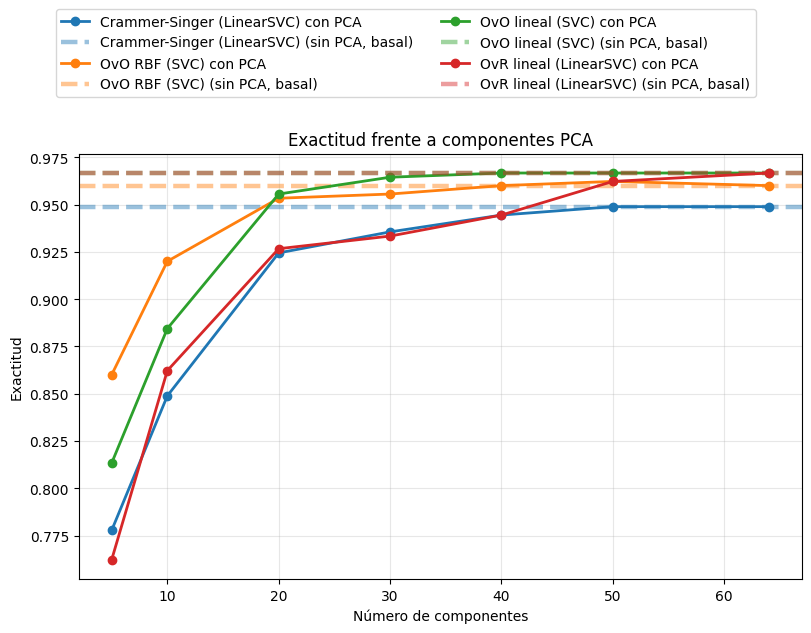

In [17]:
from IPython.display import display

# Conjunto de componentes a evaluar
componentes_pca = [5, 10, 20, 30, 40, 50, 64]

registros_componentes = []

# Entrenamiento sistemático: para cada n_componentes y cada modelo, se crea, entrena y evalúa un SVM.
for n_componentes in componentes_pca:
    for nombre, constructor in constructores_con_pca.items():
        clf = constructor(n_componentes)

        t0 = time.perf_counter()
        clf.fit(X_tr, y_tr)
        t_fit = time.perf_counter() - t0

        t0 = time.perf_counter()
        y_pred = clf.predict(X_te)
        t_pred = time.perf_counter() - t0

        registros_componentes.append({
            'Modelo': nombre,
            'Componentes PCA': n_componentes,
            'Exactitud': accuracy_score(y_te, y_pred),
            'Tiempo ajuste (s)': t_fit,
            'Tiempo predicción (s)': t_pred,
        })

tabla_componentes_pca = pd.DataFrame(registros_componentes)
tabla_componentes_pca = tabla_componentes_pca.sort_values(['Modelo', 'Componentes PCA']).reset_index(drop=True)

tabla_componentes_pca_mostrar = tabla_componentes_pca.copy()
tabla_componentes_pca_mostrar['Exactitud'] = tabla_componentes_pca_mostrar['Exactitud'].map(lambda x: f'{x:.4f}')
tabla_componentes_pca_mostrar['Tiempo ajuste (s)'] = tabla_componentes_pca_mostrar['Tiempo ajuste (s)'].map(lambda x: f'{x:.2f}')
tabla_componentes_pca_mostrar['Tiempo predicción (s)'] = tabla_componentes_pca_mostrar['Tiempo predicción (s)'].map(lambda x: f'{x:.4f}')

display(tabla_componentes_pca_mostrar)

# Recuperar métricas sin PCA para crear referencias horizontales en los gráficos
metricas_sin_pca = {
    nombre: {
        'Exactitud': res['acc_test'],
        'Tiempo ajuste (s)': res['t_fit'],
        'Tiempo predicción (s)': res['t_pred'],
    }
    for nombre, res in resultados.items()
}

# Gráficos de sensibilidad: exactitud frente a n_componentes
fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for nombre, datos_modelo in tabla_componentes_pca.groupby('Modelo'):
    linea_exactitud, = ax.plot(
        datos_modelo['Componentes PCA'],
        datos_modelo['Exactitud'],
        marker='o',
        linewidth=2,
        label=f'{nombre} con PCA'
    )
    color = linea_exactitud.get_color()

    # Líneas punteadas de referencia: rendimiento sin reducción de dimensionalidad
    referencia = metricas_sin_pca[nombre]
    ax.axhline(
        referencia['Exactitud'],
        linestyle='--',
        linewidth=3.2,
        color=color,
        alpha=0.45,
        label=f'{nombre} (sin PCA, basal)'
    )

ax.set_title('Exactitud frente a componentes PCA')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Exactitud')
ax.grid(alpha=0.3)

handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncols=2, bbox_to_anchor=(0.5, 1.25))

plt.show()

## Apéndice B. Demo interactiva con PCA

Esta demostración interactiva permite dibujar un dígito y probar diferentes números de componentes principales. Los modelos se reentrenarán automáticamente de forma transparente (el coste en este dataset es apenas de fracciones de segundo) para ofrecerte la predicción al momento con las características de PCA generadas.

In [18]:
import numpy as np
import tkinter as tk

def lanzar_demo_dibujo_pca(canvas_size_px=512, brush_ratio=0.04):
    """
    Demostración interactiva que permite dibujar un dígito en un lienzo y ver predicciones
    en tiempo real tanto sin PCA como con PCA (variable).
    
    Parámetros:
    -----------
    canvas_size_px : int
        Tamaño del lienzo en píxeles. Debe ser múltiplo de 8 para convertir a la grilla 8×8.
    brush_ratio : float
        Proporción del radio del pincel respecto al tamaño del lienzo (en [0, 1]).
    """
    if canvas_size_px % 8 != 0:
        raise ValueError("canvas_size_px debe ser múltiplo de 8 para convertir a 8x8.")
    if not (0.0 <= brush_ratio <= 1.0):
        raise ValueError("brush_ratio debe estar en el intervalo [0, 1].")

    if 'resultados' not in globals() or 'constructores_con_pca' not in globals():
        raise RuntimeError("Faltan variables globales (resultados, constructores_con_pca). Corre las celdas previas.")

    width = height = int(canvas_size_px)
    brush_radius = int(round((canvas_size_px / 2.0) * brush_ratio))

    tinta = np.zeros((height, width), dtype=np.float32)
    ultimo_punto = None
    
    # Caché para no volver a entrenar modelos para el mismo número de componentes
    modelos_cacheados = {}

    root = tk.Tk()
    root.title(f'Demo SVM Tiempo Real (PCA + No PCA) - {canvas_size_px}x{canvas_size_px}')
    try:
        root.state('zoomed')
    except tk.TclError:
        try:
            root.attributes('-zoomed', True)
        except tk.TclError:
            root.attributes('-fullscreen', True)

    # Configurar distribución global amigable con pantallas 16:9
    root.grid_rowconfigure(0, weight=1)
    root.grid_columnconfigure(0, weight=1) # Mitad izquierda (lienzos)
    root.grid_columnconfigure(1, weight=1) # Mitad derecha (tabla predicciones)

    # --- PANEL IZQUIERDO (Lienzos y Controles) ---
    frame_izq = tk.Frame(root)
    frame_izq.grid(row=0, column=0, sticky='nsew', padx=10, pady=10)

    # Controles superiores
    frame_controles = tk.Frame(frame_izq)
    frame_controles.pack(pady=(15, 5))

    tk.Label(frame_controles, text="Nº Componentes PCA:", font=('Helvetica', 14, 'bold')).pack(side=tk.LEFT, padx=10)
    n_pca_var = tk.IntVar(value=50) # Por defecto 50 componentes
    
    slider_pca = tk.Scale(
        frame_controles, from_=1, to=64, orient=tk.HORIZONTAL, length=400, 
        width=25, sliderlength=30, font=('Helvetica', 12),
        variable=n_pca_var, command=lambda v: predecir()
    )
    slider_pca.pack(side=tk.LEFT, padx=10)

    lbl_estado = tk.Label(frame_izq, text="Arrastra el ratón para dibujar sobre el lienzo", font=('Helvetica', 14, 'italic'), fg='gray')
    lbl_estado.pack(pady=5)

    # Contenedor de lienzos
    frame_lienzos = tk.Frame(frame_izq)
    frame_lienzos.pack(expand=True)

    # Lienzo de dibujo
    frame_draw = tk.Frame(frame_lienzos)
    frame_draw.grid(row=0, column=0, padx=15)
    canvas_draw = tk.Canvas(frame_draw, width=canvas_size_px, height=canvas_size_px, bg='white', cursor='cross', highlightthickness=2, highlightbackground='#bbbbbb')
    canvas_draw.pack()
    tk.Label(frame_draw, text="Dibuja aquí (✍)", font=('Helvetica', 16, 'bold')).pack(pady=10)

    # Lienzo 8x8 de visión del modelo
    frame_8x8 = tk.Frame(frame_lienzos)
    frame_8x8.grid(row=0, column=1, padx=15)
    canvas_8x8 = tk.Canvas(frame_8x8, width=canvas_size_px, height=canvas_size_px, bg='white', highlightthickness=2, highlightbackground='#bbbbbb')
    canvas_8x8.pack()
    tk.Label(frame_8x8, text="Visión del modelo (8x8)", font=('Helvetica', 16, 'bold')).pack(pady=10)

    # Botones inferiores
    frame_botones = tk.Frame(frame_izq)
    frame_botones.pack(pady=(5, 15))

    btn_limpiar = tk.Button(frame_botones, text='Limpiar (Esc)', font=('Helvetica', 14), command=lambda: limpiar(), width=15)
    btn_limpiar.grid(row=0, column=0, padx=10)

    btn_cerrar = tk.Button(frame_botones, text='Cerrar', font=('Helvetica', 14), command=root.destroy, width=15)
    btn_cerrar.grid(row=0, column=1, padx=10)

    tk.Label(frame_botones, text="💡 Usa las flechas ⬅ y ➡ para cambiar PCA rápidamente", font=('Helvetica', 12, 'italic'), fg='gray').grid(row=1, column=0, columnspan=2, pady=(10, 0))

    # --- PANEL DERECHO (Predicciones) ---
    frame_der = tk.Frame(root, relief=tk.FLAT, bg='#f4f6f9')
    frame_der.grid(row=0, column=1, sticky='nsew')
    
    # Se utiliza pack(expand=True) para que el propio Tkinter organice el contenido
    # dentro del frame disponible sin que la tabla exceda los límites invisibles.
    frame_pred_inner = tk.Frame(frame_der, bg='#f4f6f9')
    frame_pred_inner.pack(expand=True)

    tk.Label(frame_pred_inner, text="Modelo", font=('Helvetica', 22, 'bold'), bg='#f4f6f9').grid(row=0, column=0, padx=20, pady=(0, 20), sticky='w')
    tk.Label(frame_pred_inner, text="Sin PCA", font=('Helvetica', 22, 'bold'), bg='#f4f6f9', fg='#1f77b4').grid(row=0, column=1, padx=20, pady=(0, 20))
    lbl_header_pca = tk.Label(frame_pred_inner, text="Con PCA", font=('Helvetica', 22, 'bold'), bg='#f4f6f9', fg='#ff7f0e')
    lbl_header_pca.grid(row=0, column=2, padx=20, pady=(0, 20))

    nombres_modelos = list(resultados.keys())
    labels_sin_pca = {}
    labels_con_pca = {}

    for i, nombre in enumerate(nombres_modelos, start=1):
        # Abreviar nombre removiendo el paréntesis para que quepa holgadamente
        nombre_corto = nombre.split(" (")[0]
        tk.Label(frame_pred_inner, text=nombre_corto, font=('Helvetica', 18), bg='#f4f6f9').grid(row=i, column=0, padx=20, pady=15, sticky='w')
        
        lbl_sin = tk.Label(frame_pred_inner, text="-", font=('Helvetica', 32, 'bold'), bg='#f4f6f9', fg='#1f77b4')
        lbl_sin.grid(row=i, column=1, padx=20, pady=15)
        
        lbl_con = tk.Label(frame_pred_inner, text="-", font=('Helvetica', 32, 'bold'), bg='#f4f6f9', fg='#ff7f0e')
        lbl_con.grid(row=i, column=2, padx=20, pady=15)
        
        labels_sin_pca[nombre] = lbl_sin
        labels_con_pca[nombre] = lbl_con

    def obtener_modelos(n_componentes):
        """Devuelve los modelos entrenados con n_componentes. Los entrena y cachea si no existen."""
        if n_componentes not in modelos_cacheados:
            lbl_estado.config(text=f"Entrenando modelos con {n_componentes} componentes PCA...", fg='#1f77b4')
            root.update() # Refresca interfaz
            
            nuevos_modelos = {}
            for nombre, constructor in constructores_con_pca.items():
                clf = constructor(n_componentes)
                clf.fit(X_tr, y_tr)
                nuevos_modelos[nombre] = clf
                
            modelos_cacheados[n_componentes] = nuevos_modelos
            lbl_estado.config(text=f"Modelos listos (N={n_componentes})", fg='#2ca02c')
        else:
            lbl_estado.config(text=f"Modelos listos (N={n_componentes} en caché)", fg='#2ca02c')
            
        return modelos_cacheados[n_componentes]

    def obtener_img_8x8():
        step = canvas_size_px // 8
        img_8x8 = tinta.reshape(8, step, 8, step).mean(axis=(1, 3))
        max_val = float(img_8x8.max())
        if max_val > 0.0:
            img_8x8 = img_8x8 / max_val
            img_8x8 = (img_8x8 ** 1.0) * 2.0
        return img_8x8

    def predecir(_event=None):
        n_comp = n_pca_var.get()
        modelos_pca = obtener_modelos(n_comp)
        
        img_8x8 = obtener_img_8x8()
        x_input = (img_8x8 * 16.0).reshape(1, -1)
        
        lbl_header_pca.config(text=f"PCA ({n_comp})")

        for nombre, res in resultados.items():
            y_hat = int(res['clf'].predict(x_input)[0])
            labels_sin_pca[nombre].config(text=str(y_hat))
            
        for nombre, clf in modelos_pca.items():
            y_hat = int(clf.predict(x_input)[0])
            labels_con_pca[nombre].config(text=str(y_hat))

    def actualizar_vista_8x8():
        img_8x8 = obtener_img_8x8()
        canvas_8x8.delete('all')
        cell_size = canvas_size_px / 8
        for r in range(8):
            for c in range(8):
                v = int(round((1.0 - np.clip(img_8x8[r, c], 0.0, 1.0)) * 255))
                color = f'#{v:02x}{v:02x}{v:02x}'
                x0 = c * cell_size
                y0 = r * cell_size
                x1 = (c + 1) * cell_size
                y1 = (r + 1) * cell_size
                canvas_8x8.create_rectangle(x0, y0, x1, y1, fill=color, outline=color)

    def actualizar_todo():
        actualizar_vista_8x8()
        predecir()

    def pintar_en_matriz(cx, cy):
        if brush_radius <= 0:
            tinta[cy, cx] = 1.0
            return
        y_grid, x_grid = np.ogrid[:height, :width]
        mask = (x_grid - cx) ** 2 + (y_grid - cy) ** 2 <= brush_radius ** 2
        tinta[mask] = 1.0

    def pintar_segmento_en_matriz(x0, y0, x1, y1):
        dx = x1 - x0
        dy = y1 - y0
        pasos = max(1, int(np.hypot(dx, dy)))
        for i in range(pasos + 1):
            t = i / pasos
            xi = int(round(x0 + t * dx))
            yi = int(round(y0 + t * dy))
            xi = max(0, min(width - 1, xi))
            yi = max(0, min(height - 1, yi))
            pintar_en_matriz(xi, yi)

    def normalizar_coordenadas(event):
        x = max(0, min(canvas_size_px - 1, event.x))
        y = max(0, min(canvas_size_px - 1, event.y))
        return x, y

    def iniciar_trazo(event):
        nonlocal ultimo_punto
        x, y = normalizar_coordenadas(event)
        ultimo_punto = (x, y)
        pintar_en_matriz(x, y)
        
        if brush_radius > 0:
            canvas_draw.create_oval(
                x - brush_radius, y - brush_radius,
                x + brush_radius, y + brush_radius,
                fill='black', outline='black'
            )
        else:
            canvas_draw.create_rectangle(
                x, y, x + 1, y + 1,
                fill='black', outline='black'
            )
        actualizar_todo()

    def continuar_trazo(event):
        nonlocal ultimo_punto
        x, y = normalizar_coordenadas(event)

        if ultimo_punto is None:
            iniciar_trazo(event)
            return

        x0, y0 = ultimo_punto

        canvas_draw.create_line(
            x0, y0, x, y,
            fill='black',
            width=max(1, 2 * brush_radius),
            capstyle=tk.ROUND,
            joinstyle=tk.ROUND,
            smooth=True
        )

        pintar_segmento_en_matriz(x0, y0, x, y)
        ultimo_punto = (x, y)
        actualizar_todo()

    def terminar_trazo(_event=None):
        nonlocal ultimo_punto
        ultimo_punto = None
        actualizar_todo()

    def limpiar(_event=None):
        nonlocal ultimo_punto
        tinta.fill(0.0)
        canvas_draw.delete('all')
        ultimo_punto = None
        actualizar_todo()

    # Controles de teclado
    def dec_pca(_event=None):
        v = n_pca_var.get()
        if v > 1:
            n_pca_var.set(v - 1)
            predecir()

    def inc_pca(_event=None):
        v = n_pca_var.get()
        if v < 64:
            n_pca_var.set(v + 1)
            predecir()

    # Asignar atajos de teclado y ratón
    canvas_draw.bind('<Button-1>', iniciar_trazo)
    canvas_draw.bind('<B1-Motion>', continuar_trazo)
    canvas_draw.bind('<ButtonRelease-1>', terminar_trazo)
    
    root.bind('<Escape>', limpiar)
    root.bind('<Left>', dec_pca)
    root.bind('<Right>', inc_pca)
    
    # Inicializamos la vista al abrir
    actualizar_todo()
    root.mainloop()

# Ejecutar la aplicación interactiva final con lienzos más grandes y layout flexible
lanzar_demo_dibujo_pca(canvas_size_px=512, brush_ratio=0.04)

/home/hugo/.local/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
